In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Dataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import numpy as np
import os
import re
from pathlib import Path
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


In [ ]:
# Custom Dataset that loads networks on-the-fly
class NetworkDataset(Dataset):
    def __init__(self, root_dir, transform=None, pre_transform=None):
        self.root_dir = Path(root_dir)
        self.file_list = list(self.root_dir.glob("*.npy"))
        super().__init__(root_dir, transform, pre_transform)
        
    def len(self):
        return len(self.file_list)
    
    def get(self, idx):
        # Load network
        filepath = self.file_list[idx]
        adj_matrix = np.load(filepath)[0]  # Shape: (100, 100)
        
        # Extract eta and gamma from filename
        filename = filepath.name
        eta_match = re.search(r'eta-([\d.]+)', filename)
        gamma_match = re.search(r'gamma-([\d.]+)', filename)
        
        eta = float(eta_match.group(1))
        gamma = float(gamma_match.group(1))
        
        # Convert adjacency matrix to edge_index and edge_weight
        edge_index, edge_weight = self._adj_to_edge_index(adj_matrix)
        
        # Node features (you can customize this)
        # Option 1: Use node degree as features
        node_features = self._compute_node_features(adj_matrix)
        
        # Create PyG Data object
        data = Data(
            x=torch.tensor(node_features, dtype=torch.float),
            edge_index=edge_index,
            edge_attr=edge_weight,
            y=torch.tensor([[eta, gamma]], dtype=torch.float),  # y=torch.tensor([eta, gamma], dtype=torch.float)
        )
        
        return data
    
    
    def _adj_to_edge_index(self, adj_matrix):
        """Convert adjacency matrix to edge_index and edge_weight"""
        # Get non-zero edges
        rows, cols = np.nonzero(adj_matrix)
        edge_index = torch.tensor([rows, cols], dtype=torch.long)
        edge_weight = torch.tensor(adj_matrix[rows, cols], dtype=torch.float).unsqueeze(1)
        
        return edge_index, edge_weight
    
    
    def _compute_node_features(self, adj_matrix):
        """Compute node features from adjacency matrix"""
        # Multiple feature options - choose what makes sense for your data
        
        # Degree (weighted and unweighted)
        degree = adj_matrix.sum(axis=1, keepdims=True)
        binary_degree = (adj_matrix > 0).sum(axis=1, keepdims=True)
        
        # Clustering coefficient approximation
        # For weighted networks, you might want to add more features
        
        # Simple option: just use identity + degree
        num_nodes = adj_matrix.shape[0]
        identity = np.eye(num_nodes)
        
        features = np.hstack([
            identity,  # Node identity (100 features)
            degree,    # Weighted degree (1 feature)
            binary_degree  # Binary degree (1 feature)
        ])
        
        # Or simpler: just degree
        # features = np.hstack([degree, binary_degree])
        
        return features


In [20]:


# GNN Model for regression
class NetworkGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2):
        super().__init__()
        
        # GNN layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        # Prediction head
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, out_channels)  # Predict [eta, gamma]
        
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, data):
        x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        # GNN layers with edge weights
        x = self.conv1(x, edge_index, edge_weight.squeeze())
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index, edge_weight.squeeze())
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv3(x, edge_index, edge_weight.squeeze())
        x = F.relu(x)
        
        # Global pooling (graph-level representation)
        x = global_mean_pool(x, batch)
        
        # Prediction layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


# Training function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data)
        loss = criterion(out, data.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(loader.dataset)


# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out, data.y)
            
            total_loss += loss.item() * data.num_graphs
            predictions.append(out.cpu())
            targets.append(data.y.cpu())
    
    predictions = torch.cat(predictions, dim=0)
    targets = torch.cat(targets, dim=0)
    
    return total_loss / len(loader.dataset), predictions, targets


# Main training script
def main():
    # Configuration
    network_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/generated_networks"
    batch_size = 32
    num_epochs = 100
    learning_rate = 0.001
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load dataset
    print("Loading dataset...")
    dataset = NetworkDataset(network_dir)
    print(f"Total networks: {len(dataset)}")
    
    # Check a sample
    sample = dataset[0]
    print(f"Sample data - Nodes: {sample.x.shape[0]}, Edges: {sample.edge_index.shape[1]}")
    print(f"Node features: {sample.x.shape[1]}, Target: {sample.y}")
    
    # Split dataset
    indices = list(range(len(dataset)))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=42)
    
    train_dataset = [dataset[i] for i in train_idx]
    val_dataset = [dataset[i] for i in val_idx]
    test_dataset = [dataset[i] for i in test_idx]
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Initialize model
    in_channels = sample.x.shape[1]
    model = NetworkGNN(in_channels=in_channels, hidden_channels=64, out_channels=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters())}")
    
    # Training loop
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
        
        # Calculate MAE for interpretability
        mae_eta = torch.abs(val_preds[:, 0] - val_targets[:, 0]).mean()
        mae_gamma = torch.abs(val_preds[:, 1] - val_targets[:, 1]).mean()
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")
        print(f"  MAE - Eta: {mae_eta:.6f}, Gamma: {mae_gamma:.6f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print("  ✓ Saved best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    # Test evaluation
    model.load_state_dict(torch.load('best_model.pt'))
    test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion, device)
    
    mae_eta = torch.abs(test_preds[:, 0] - test_targets[:, 0]).mean()
    mae_gamma = torch.abs(test_preds[:, 1] - test_targets[:, 1]).mean()
    
    print(f"\n{'='*50}")
    print(f"TEST RESULTS:")
    print(f"  Test Loss: {test_loss:.6f}")
    print(f"  MAE - Eta: {mae_eta:.6f}, Gamma: {mae_gamma:.6f}")
    print(f"{'='*50}")
    
    # Save predictions for analysis
    np.save('test_predictions.npy', test_preds.numpy())
    np.save('test_targets.npy', test_targets.numpy())
    
    return model, test_preds, test_targets


In [6]:
# model, preds, targets = main()


In [ ]:
# Configuration
network_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/generated_networks"
batch_size = 32
num_epochs = 100
learning_rate = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # TODO: Add apple support 

In [19]:
dataset.get(1)

AttributeError: 'NoneType' object has no attribute 'group'

In [16]:
# Load dataset
print("Loading dataset...")
dataset = NetworkDataset(network_dir)
print(f"Total networks: {len(dataset)}")

# Check a sample
sample = dataset.get(0)
print(f"Sample data - Nodes: {sample.x.shape[0]}, Edges: {sample.edge_index.shape[1]}")
print(f"Node features: {sample.x.shape[1]}, Target: {sample.y}")

# Split dataset
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=42)

train_dataset = [dataset.get(i) for i in train_idx]
val_dataset = [dataset.get(i) for i in val_idx]
test_dataset = [dataset.get(i) for i in test_idx]

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


Loading dataset...
Total networks: 25000
Sample data - Nodes: 100, Edges: 1188
Node features: 102, Target: tensor([3.5102, 0.0551])


AttributeError: 'NoneType' object has no attribute 'group'

In [ ]:


# Initialize model
in_channels = sample.x.shape[1]
model = NetworkGNN(in_channels=in_channels, hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
criterion = nn.MSELoss()

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters())}")

# Training loop
best_val_loss = float('inf')
patience = 15
patience_counter = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
    
    # Calculate MAE for interpretability
    mae_eta = torch.abs(val_preds[:, 0] - val_targets[:, 0]).mean()
    mae_gamma = torch.abs(val_preds[:, 1] - val_targets[:, 1]).mean()
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.6f}")
    print(f"  Val Loss: {val_loss:.6f}")
    print(f"  MAE - Eta: {mae_eta:.6f}, Gamma: {mae_gamma:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print("  ✓ Saved best model")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Test evaluation
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion, device)

mae_eta = torch.abs(test_preds[:, 0] - test_targets[:, 0]).mean()
mae_gamma = torch.abs(test_preds[:, 1] - test_targets[:, 1]).mean()

print(f"\n{'='*50}")
print(f"TEST RESULTS:")
print(f"  Test Loss: {test_loss:.6f}")
print(f"  MAE - Eta: {mae_eta:.6f}, Gamma: {mae_gamma:.6f}")
print(f"{'='*50}")

# Save predictions for analysis
np.save('test_predictions.npy', test_preds.numpy())
np.save('test_targets.npy', test_targets.numpy())

# New

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Dataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import numpy as np
import os
import re
from pathlib import Path
from sklearn.model_selection import train_test_split

# Custom Dataset that loads networks on-the-fly
class NetworkDataset(Dataset):
    def __init__(self, root_dir, transform=None, pre_transform=None):
        self.root_dir = Path(root_dir)
        self.file_list = list(self.root_dir.glob("*.npy"))
        
        # Filter out files that don't have proper eta/gamma values
        valid_files = []
        for f in self.file_list:
            if self._parse_filename(f.name) is not None:
                valid_files.append(f)
        
        self.file_list = valid_files
        print(f"Found {len(self.file_list)} valid network files")
        
        super().__init__(root_dir, transform, pre_transform)
    
    def _parse_filename(self, filename):
        """Extract eta and gamma from filename, return None if not found"""
        try:
            # More flexible regex patterns
            eta_match = re.search(r'eta-?([\d.eE+-]+)', filename)
            gamma_match = re.search(r'gamma-?([\d.eE+-]+)', filename)
            
            if eta_match and gamma_match:
                eta = float(eta_match.group(1))
                gamma = float(gamma_match.group(1))
                return eta, gamma
            else:
                return None
        except (ValueError, AttributeError) as e:
            print(f"Warning: Could not parse {filename}: {e}")
            return None
        
    def len(self):
        return len(self.file_list)
    
    def get(self, idx):
        # Load network
        filepath = self.file_list[idx]
        adj_matrix = np.load(filepath)[0]  # Shape: (100, 100)
        
        # Extract eta and gamma from filename
        filename = filepath.name
        result = self._parse_filename(filename)
        
        if result is None:
            raise ValueError(f"Could not parse eta/gamma from {filename}")
        
        eta, gamma = result
        
        # Convert adjacency matrix to edge_index and edge_weight
        edge_index, edge_weight = self._adj_to_edge_index(adj_matrix)
        
        # Node features
        node_features = self._compute_node_features(adj_matrix)
        
        # Create PyG Data object
        data = Data(
            x=torch.tensor(node_features, dtype=torch.float),
            edge_index=edge_index,
            edge_attr=edge_weight,
            y=torch.tensor([[eta, gamma]], dtype=torch.float),  # y=torch.tensor([eta, gamma], dtype=torch.float),
            filename=filename  # Store for debugging
        )
        
        return data
    
    def _adj_to_edge_index(self, adj_matrix):
        """Convert adjacency matrix to edge_index and edge_weight"""
        # Get non-zero edges
        rows, cols = np.nonzero(adj_matrix)
        
        if len(rows) == 0:
            # Handle empty graphs
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            edge_weight = torch.zeros((0, 1), dtype=torch.float)
        else:
            edge_index = torch.tensor([rows, cols], dtype=torch.long)
            edge_weight = torch.tensor(adj_matrix[rows, cols], dtype=torch.float).unsqueeze(1)
        
        return edge_index, edge_weight
    
    def _compute_node_features(self, adj_matrix):
        """Compute node features from adjacency matrix"""
        # Degree (weighted and unweighted)
        degree = adj_matrix.sum(axis=1, keepdims=True)
        binary_degree = (adj_matrix > 0).sum(axis=1, keepdims=True)
        
        # Normalize degrees to help with training
        degree = degree / (degree.max() + 1e-6)
        binary_degree = binary_degree / (binary_degree.max() + 1e-6)
        
        # Option 1: Simple features (recommended to start)
        features = np.hstack([degree, binary_degree])
        
        # Option 2: Add node identity (uncomment if you want)
        # num_nodes = adj_matrix.shape[0]
        # identity = np.eye(num_nodes)
        # features = np.hstack([identity, degree, binary_degree])
        
        return features


# GNN Model for regression
class NetworkGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2):
        super().__init__()
        
        # GNN layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        # Prediction head
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, out_channels)  # Predict [eta, gamma]
        
        self.dropout = nn.Dropout(0.3)
        
    # def forward(self, data):
    #     x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
    #     # Handle edge weights (some graphs might have no edges)
    #     if edge_weight.shape[0] > 0:
    #         edge_weight = edge_weight.squeeze()
    #     else:
    #         edge_weight = None
        
    #     # GNN layers with edge weights
    #     x = self.conv1(x, edge_index, edge_weight)
    #     x = F.relu(x)
    #     x = self.dropout(x)
        
    #     x = self.conv2(x, edge_index, edge_weight)
    #     x = F.relu(x)
    #     x = self.dropout(x)
        
    #     x = self.conv3(x, edge_index, edge_weight)
    #     x = F.relu(x)
        
    #     # Global pooling (graph-level representation)
    #     x = global_mean_pool(x, batch)
        
    #     # Prediction layers
    #     x = self.fc1(x)
    #     x = F.relu(x)
    #     x = self.dropout(x)
    #     x = self.fc2(x)
        
    #     return x
    
    def forward(self, data):
        x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        # Handle edge weights (some graphs might have no edges)
        if edge_weight.shape[0] > 0:
            edge_weight = edge_weight.squeeze()
        else:
            edge_weight = None
        
        # GNN layers with edge weights
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv3(x, edge_index, edge_weight)
        x = F.relu(x)
        
        # Global pooling (graph-level representation)
        x = global_mean_pool(x, batch)
        
        # Prediction layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


# Training function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data)
        print(f"Output shape: {out.shape}, Target shape: {data.y.shape}")
        loss = criterion(out, data.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(loader.dataset)


# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out, data.y)
            
            total_loss += loss.item() * data.num_graphs
            predictions.append(out.cpu())
            targets.append(data.y.cpu())
    
    predictions = torch.cat(predictions, dim=0)
    targets = torch.cat(targets, dim=0)
    
    return total_loss / len(loader.dataset), predictions, targets


# Main training script
def main():
    # Configuration
    network_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/generated_networks"
    batch_size = 32
    num_epochs = 100
    learning_rate = 0.001
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load dataset
    print("Loading dataset...")
    dataset = NetworkDataset(network_dir)
    print(f"Total valid networks: {len(dataset)}")
    
    if len(dataset) == 0:
        print("ERROR: No valid networks found!")
        print("Please check your directory and filename format.")
        return
    
    # Check a sample
    sample = dataset[0]
    print(f"\nSample data:")
    print(f"  Nodes: {sample.x.shape[0]}")
    print(f"  Edges: {sample.edge_index.shape[1]}")
    print(f"  Node features: {sample.x.shape[1]}")
    print(f"  Target (eta, gamma): {sample.y}")
    print(f"  Filename: {sample.filename}")
    
    # Split dataset
    indices = list(range(len(dataset)))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=42)
    
    train_dataset = [dataset[i] for i in train_idx]
    val_dataset = [dataset[i] for i in val_idx]
    test_dataset = [dataset[i] for i in test_idx]
    
    print(f"\nDataset splits:")
    print(f"  Train: {len(train_dataset)}")
    print(f"  Val: {len(val_dataset)}")
    print(f"  Test: {len(test_dataset)}")
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    
    
    # Right before "Initialize model" section:
    print(f"\nChecking batch:")
    for data in train_loader:
        print(f"Batch size: {data.num_graphs}")
        print(f"x shape: {data.x.shape}")
        print(f"y shape: {data.y.shape}")
        print(f"batch shape: {data.batch.shape}")
        break

    # Initialize model
    in_channels = sample.x.shape[1]
    model = NetworkGNN(in_channels=in_channels, hidden_channels=64, out_channels=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters())}")
    print(f"Device: {device}\n")
    
    # Training loop
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
        
        # Calculate MAE for interpretability
        mae_eta = torch.abs(val_preds[:, 0] - val_targets[:, 0]).mean()
        mae_gamma = torch.abs(val_preds[:, 1] - val_targets[:, 1]).mean()
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")
        print(f"  MAE - Eta: {mae_eta:.6f}, Gamma: {mae_gamma:.6f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print("  ✓ Saved best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    # Test evaluation
    model.load_state_dict(torch.load('best_model.pt'))
    test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion, device)
    
    mae_eta = torch.abs(test_preds[:, 0] - test_targets[:, 0]).mean()
    mae_gamma = torch.abs(test_preds[:, 1] - test_targets[:, 1]).mean()
    
    print(f"\n{'='*50}")
    print(f"TEST RESULTS:")
    print(f"  Test Loss: {test_loss:.6f}")
    print(f"  MAE - Eta: {mae_eta:.6f}, Gamma: {mae_gamma:.6f}")
    print(f"{'='*50}")
    
    # Save predictions for analysis
    np.save('test_predictions.npy', test_preds.numpy())
    np.save('test_targets.npy', test_targets.numpy())
    
    return model, test_preds, test_targets


if __name__ == "__main__":
    model, preds, targets = main()

Loading dataset...
Found 25000 valid network files
Total valid networks: 25000

Sample data:
  Nodes: 100
  Edges: 1188
  Node features: 2
  Target (eta, gamma): tensor([[3.5102, 0.0551]])
  Filename: net_eta-3.510204076766968_gamma-0.055102042853833_ruleMatchingIndex_id008.npy

Dataset splits:
  Train: 18000
  Val: 2000
  Test: 5000

Checking batch:
Batch size: 32
x shape: torch.Size([3200, 2])
y shape: torch.Size([32, 2])
batch shape: torch.Size([3200])

Model parameters: 10658
Device: cpu

Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch.Size([32, 2]), Target shape: torch.Size([32, 2])
Output shape: torch

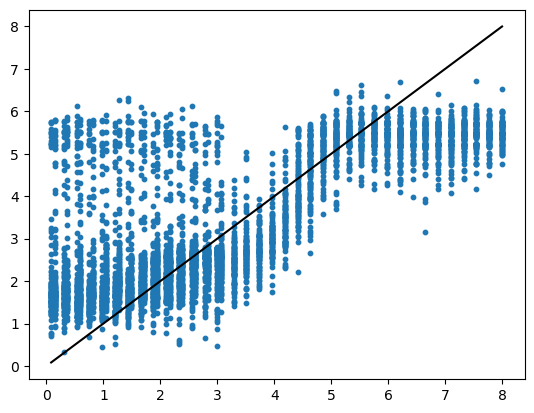

In [46]:
plt.scatter(targets[:, 0], preds[:, 0], s=10)
plt.plot([targets[:, 0].min(), targets[:, 0].max()], [targets[:, 0].min(), targets[:, 0].max()], c="black") # , 'black', '--')
# plt.xlabel('True Eta')
# plt.ylabel('Predicted Eta')


Text(0, 0.5, 'Predicted Gamma')

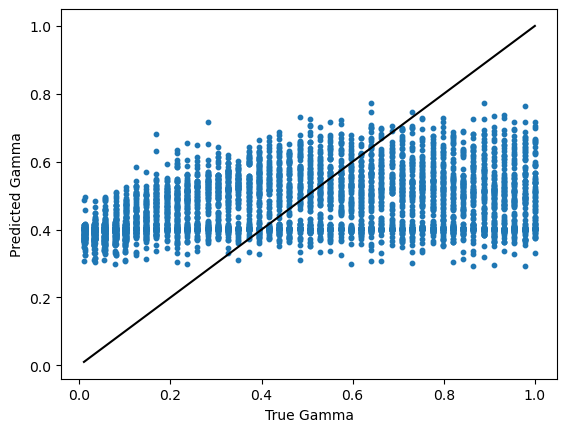

In [45]:
# Now for gamma
plt.scatter(targets[:, 1], preds[:, 1], s=10)
plt.plot([targets[:, 1].min(), targets[:, 1].max()], [targets[:, 1].min(), targets[:, 1].max()], c='black') # , '--')
plt.xlabel('True Gamma')
plt.ylabel('Predicted Gamma')